In [1]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import t, norm

In [2]:
def get_stock_data(ticker, max, start_date, end_date):
    try:
        # https://medium.com/nerd-for-tech/all-you-need-to-know-about-yfinance-yahoo-finance-library-fa4c6e48f08e
        data = yf.Ticker(ticker)
        if max == False:
            data = data.history(start=start_date, end=end_date)
        else:
            data = data.history(period="max")
        return data
    except Exception as e:
        return f"Error fetching data: {e}"

In [3]:
#demo index
stock_data = get_stock_data("PREIX", False,"2000-01-01", "2024-10-01")
stock_data.asfreq('B').index  # set index frequency to business daliy
stock_data['Daily Return'] = stock_data['Close'].pct_change()  # percentage return

In [4]:
#simple threshold determination (based on SD, mean, etc. -- to be experimented with)

mean_return = stock_data['Daily Return'].mean()
std_return = stock_data['Daily Return'].std()

# Define thresholds
up_threshold = mean_return + std_return
down_threshold = mean_return - std_return

def classify_state(return_value, up_thresh, down_thresh):
    if return_value > up_thresh:
        return 'Up'
    elif return_value < down_thresh:
        return 'Down'
    else:
        return 'Stagnant'

stock_data['Markov State'] = stock_data['Daily Return'].apply(lambda x: classify_state(x, up_threshold, down_threshold))

In [5]:
#transition matrix creation (probabilities of achieving various states based on prev states)

# Shift 'Markov State' column to get previous state
stock_data['Prev State'] = stock_data['Markov State'].shift(1)

# Create a transition matrix and Normalize to get probabilities
transition_counts = pd.crosstab(stock_data['Prev State'], stock_data['Markov State'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

In [6]:
#establish stationary equilibrium matrix

def find_equilibrium(transition_matrix):
    # Add a small number to ensure the matrix is not singular
    transition_matrix = transition_matrix + 1e-6
    # Initialize the equilibrium vector
    equilibrium = np.random.rand(transition_matrix.shape[0])
    # Normalize the equilibrium vector
    equilibrium = equilibrium / np.sum(equilibrium)
    # Iterate until convergence
    while True:
        new_equilibrium = np.dot(equilibrium, transition_matrix)
        # Check for convergence
        if np.allclose(equilibrium, new_equilibrium):
            break
        # Update the equilibrium vector
        equilibrium = new_equilibrium
    return equilibrium

# Calculate transition matrix

equilibrium = find_equilibrium(transition_matrix)
print(equilibrium)

[0.10925787 0.79227022 0.09849291]


normalizing vectors vs normalizing matrices? research further to ensure you fully comprehend

Transition Matrix:
 Markov State      Down  Stagnant        Up
Prev State                                
Down          0.158824  0.650000  0.191176
Stagnant      0.095315  0.821132  0.083553
Up            0.166395  0.717781  0.115824


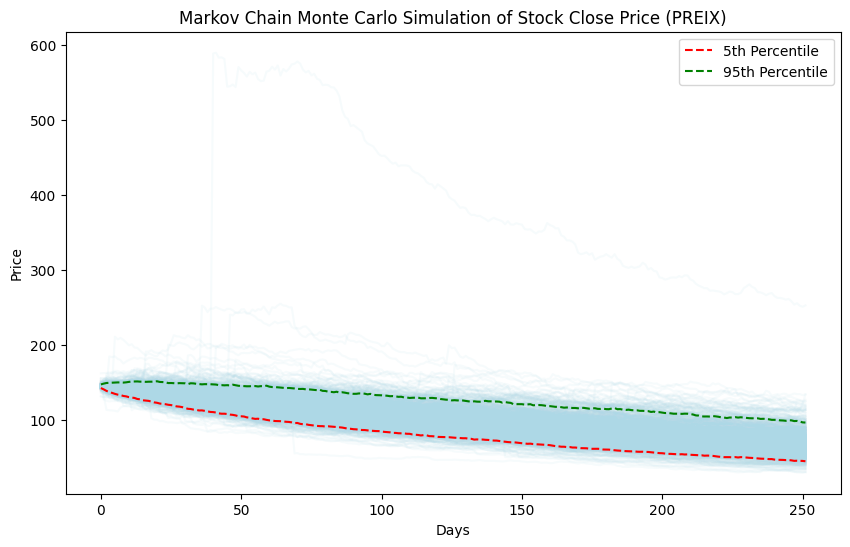

In [ ]:
#mc sim

# Fit the Student's t distribution to the returns data
params = t.fit(stock_data['Daily Return'].dropna())

# Get the parameters of the distribution
df_t, mu, sigma = params

# from above
print("Transition Matrix:\n", transition_matrix)
initial_price = stock_data['Close'].iloc[-1]  # Initial stock price
states = ["Up", "Down", "Stagnant"] #reexammine this definition here

# 4. Monte Carlo Simulation based on Markov Chain
n_simulations = 1000  # Number of simulation paths
n_days = 252  # Simulate for 1 year (252 trading days)

# Initial state probabilities
initial_state = stock_data['Markov State'].iloc[-1]
initial_state_probabilities = [1 if state == initial_state else 0 for state in states]

# Simulating the paths
simulated_paths = []
for sim in range(n_simulations):
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    
    for day in range(n_days):
        # Simulate return based on the current state using Student's t-distribution
        if current_state == "Up":
            daily_return = t.rvs(df_t, loc=mu + sigma, scale=sigma)
        elif current_state == "Down":
            daily_return = t.rvs(df_t, loc=mu - sigma, scale=sigma)
        else:
            daily_return = t.rvs(df_t, loc=mu, scale=sigma)
        
        simulated_returns.append(daily_return)
        # Transition to the next state based on the transition matrix
        current_state = np.random.choice(states, p=transition_matrix.loc[current_state].values)
    
    # Cumulative price based on returns
    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns))
    simulated_paths.append(simulated_prices)

# Convert the list of paths to a DataFrame
simulated_paths_df = pd.DataFrame(simulated_paths).T

# 5. Plotting the Monte Carlo simulation
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = simulated_paths_df.quantile(0.05, axis=1)
percentiles_95 = simulated_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"Markov Chain Monte Carlo Simulation of Stock Close Price ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


In [10]:
#mc extra adds

# 6. Computing VaR (Value at Risk)
final_prices = simulated_paths_df.iloc[-1]
losses = initial_price - final_prices
confidence_level = 0.95

# VaR at 95% confidence level
var_95 = np.percentile(losses, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at 95% confidence level: {var_95:.2f}")

# 7. Computing Confidence Intervals
mean_final_price = np.mean(final_prices)
std_final_price = np.std(final_prices)
ci_95 = norm.interval(0.95, loc=mean_final_price, scale=std_final_price)

print(f"95% Confidence Interval for the final price: {ci_95}")

Value at Risk (VaR) at 95% confidence level: 48.42
95% Confidence Interval for the final price: (np.float64(35.0250456407255), np.float64(101.77426521712837))
